In [62]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class MACDBacktester():
    def __init__(self, symbol, fast_ema, slow_ema, signal_ema, start, end):
        self.symbol = symbol
        self.fast_ema = fast_ema
        self.slow_ema = slow_ema
        self.signal_ema = signal_ema
        self.start = start
        self.end = end
        self.results = None
        self.get_data()
        
    def get_data(self):
        df = yf.download(self.symbol, start=self.start, end=self.end)[['Close']]
        data = df
        data["returns"] = np.log(data.Close.div(data.Close.shift(1)))
        
        # Calculate MACD
        exp1 = data.Close.ewm(span=self.fast_ema, adjust=False).mean()
        exp2 = data.Close.ewm(span=self.slow_ema, adjust=False).mean()
        data["MACD"] = exp1 - exp2
        data["Signal"] = data["MACD"].ewm(span=self.signal_ema, adjust=False).mean()
        data["MACD_Hist"] = data["MACD"] - data["Signal"]
        data.dropna(inplace=True)
        self.data2 = data
        return data
    
    def test_results(self):
        data = self.data2.copy().dropna()
        # Strategy 1: MACD vs Zero Line
        data["position_zero"] = np.where(data["MACD"] > 0, 1, -1)
        data["strategy_zero"] = data["returns"] * data.position_zero.shift(1)
        
        # Strategy 2: MACD vs Signal Line
        data["position_signal"] = np.where(data["MACD"] > data["Signal"], 1, -1)
        data["strategy_signal"] = data["returns"] * data.position_signal.shift(1)
        
        data.dropna(inplace=True)
        
        # Calculate cumulative returns
        data["returnsbh"] = data["returns"].cumsum().apply(np.exp)
        data["returnsstrategy_zero"] = data["strategy_zero"].cumsum().apply(np.exp)
        data["returnsstrategy_signal"] = data["strategy_signal"].cumsum().apply(np.exp)
        
        # Performance metrics
        perf_zero = data["returnsstrategy_zero"].iloc[-1]
        outperf_zero = perf_zero - data["returnsbh"].iloc[-1]
        perf_signal = data["returnsstrategy_signal"].iloc[-1]
        outperf_signal = perf_signal - data["returnsbh"].iloc[-1]
        
        self.results = data
        ret_zero = np.exp(data["strategy_zero"].sum())
        std_zero = data["strategy_zero"].std() * np.sqrt(252)
        ret_signal = np.exp(data["strategy_signal"].sum())
        std_signal = data["strategy_signal"].std() * np.sqrt(252)
        
        return (round(perf_zero, 6), round(outperf_zero, 6),
                round(perf_signal, 6), round(outperf_signal, 6))
    
    def plot_results(self):
        if self.results is None:
            print("Run the test please")
        else:
            title = f"{self.symbol} | MACD({self.fast_ema},{self.slow_ema},{self.signal_ema})"
            plt.style.use("seaborn-v0_8")
            self.results[["returnsbh", "returnsstrategy_zero", "returnsstrategy_signal"]].plot(
                title=title, 
                figsize=(12, 8),
                label=["Buy & Hold", "MACD vs Zero", "MACD vs Signal"]
            )
            plt.legend(loc="upper left", fontsize=12)
            plt.show()
    
    def plot_macd(self):
        data = self.data2.copy()
        plt.style.use("seaborn-v0_8")
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [3, 1]})
        
        # Plot price
        ax1.plot(data.index, data["Close"], label="Close Price")
        ax1.set_title(f"{self.symbol} Price and MACD", fontsize=15)
        ax1.legend(loc="upper left", fontsize=12)
        
        # Plot MACD
        ax2.plot(data.index, data["MACD"], label="MACD", color="blue")
        ax2.plot(data.index, data["Signal"], label="Signal", color="orange")
        ax2.axhline(y=0, color='k', linestyle='-', alpha=0.3)
        ax2.fill_between(data.index, data["MACD_Hist"], 0, alpha=0.3, color='gray')
        ax2.legend(loc="upper left", fontsize=12)
        
        plt.tight_layout()
        plt.show()
    
    def plot_return_histogram(self):
        data = self.data2.copy()
        ret = data["Close"].pct_change().mul(100).dropna()
        plt.style.use("seaborn-v0_8")
        ret.plot(kind="hist", figsize=(12, 8), bins=100)
        plt.title(f"{self.symbol} Daily Return Distribution", fontsize=15)
        plt.xlabel("Daily Return (%)", fontsize=15)
        plt.ylabel("Frequency", fontsize=15)
        plt.show()

In [63]:
tester = MACDBacktester("SPY", 12, 26, 9, "2020-06-01", "2025-06-25")

/var/folders/4z/0p4c7jt52_d1bq34q6bc_x800000gn/T/ipykernel_48864/2089423497.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(self.symbol, start=self.start, end=self.end)[['Close']]
[*********************100%***********************]  1 of 1 completed


In [64]:
tester.test_results()

(1.281677, -0.842889, 0.914155, -1.210411)

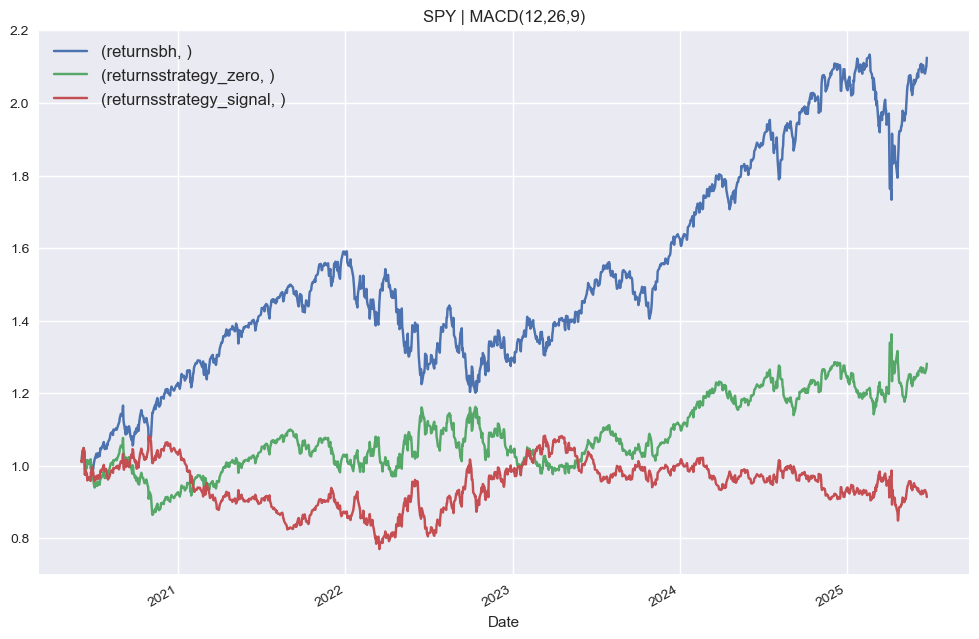

In [65]:
tester.plot_results()